# Rede Neural

Imports

In [1]:
from src.objetos import Dados, camada_densa, rede_neural

Caminho contendo os dados das imagens e os rótulos correspondentes.

In [2]:
caminho_dados = r"dados/imageMNIST.csv"
caminho_rotulos = r"dados/labelMNIST.csv"

Inicialização dos dados

In [3]:
dados = Dados(caminho_dados=caminho_dados, caminho_rotulos=caminho_rotulos)

Método de separação dos dados

In [4]:
dados._holdout(0.6, 0.2)

Parâmetros da rede neural

In [5]:
epocas = 500
taxa_aprendizado = 0.5
lambda_reg = None
# [A,B,C] : A -> B -> C
arquitetura_camadas = [400, 25, 10]

Inicialização das camadas

In [6]:
camadas = []

for i in range(len(arquitetura_camadas)-1):
    camada = camada_densa.CamadaDensa(
        tamanho_entrada=arquitetura_camadas[i], 
        tamanho_saida=arquitetura_camadas[i+1],
        funcao_de_ativacao='entropia_cruzada'
        )
    camadas.append(camada)


Inicialização da rede neural

In [7]:
rede = rede_neural.RedeNeural(camadas=camadas,funcao_de_custo="entropia_cruzada", regularizador_lambda=lambda_reg)

Treinamento da rede

In [8]:
rede.treinar(
    epocas=epocas,
    taxa_aprendizado=taxa_aprendizado,
    conjunto_treinamento=dados.conjunto_treinamento,
    conjunto_validacao=dados.conjunto_validacao,
    regularizador_lambda=lambda_reg
)

Leitura dos Logs

In [9]:
import pandas as pd

logs = pd.read_csv("logs.csv")

# Resultado

Acurácia com base no conjunto de teste

In [10]:
import numpy as np
y_teste = rede._avalia(dados.conjunto_teste[0])
classes_pred = np.argmax(y_teste, axis=0) + 1
classes_real = np.argmax(dados.conjunto_teste[1], axis=0) + 1
acertos = np.sum(classes_pred == classes_real)
num_amostras = dados.conjunto_teste[0].shape[1]

acuracia_modelo = acertos/num_amostras

print(acuracia_modelo)

0.916


Imagens do conjunto de teste classificadas incorretamente

In [11]:
for i in range(num_amostras):
    if (classes_pred[i] != classes_real[i]):
        comparacao = np.all(dados.pacote_dados == dados.conjunto_teste[0].T[i], axis=1)
        indice = np.where(comparacao)[0]
        print(indice)
        print(f"Classe prevista: {classes_pred[i]}")
        print(f"Classe real: {classes_real[i]}")

[4999]
Classe prevista: 10
Classe real: 9
[2913]
Classe prevista: 10
Classe real: 5
[2047]
Classe prevista: 6
Classe real: 4
[2818]
Classe prevista: 10
Classe real: 5
[2919]
Classe prevista: 8
Classe real: 5
[2399]
Classe prevista: 9
Classe real: 4
[4100]
Classe prevista: 1
Classe real: 8
[3619]
Classe prevista: 4
Classe real: 7
[2575]
Classe prevista: 8
Classe real: 5
[1383]
Classe prevista: 8
Classe real: 2
[2598]
Classe prevista: 6
Classe real: 5
[4593]
Classe prevista: 10
Classe real: 9
[4177]
Classe prevista: 3
Classe real: 8
[1014]
Classe prevista: 10
Classe real: 2
[4990]
Classe prevista: 3
Classe real: 9
[4541]
Classe prevista: 4
Classe real: 9
[2620]
Classe prevista: 10
Classe real: 5
[1936]
Classe prevista: 5
Classe real: 3
[1815]
Classe prevista: 2
Classe real: 3
[3823]
Classe prevista: 1
Classe real: 7
[4429]
Classe prevista: 9
Classe real: 8
[2078]
Classe prevista: 9
Classe real: 4
[1069]
Classe prevista: 7
Classe real: 2
[4293]
Classe prevista: 5
Classe real: 8
[1207]
Cla

Gráfico do custo de treinamento e do custo de validação em função da época de treinamento

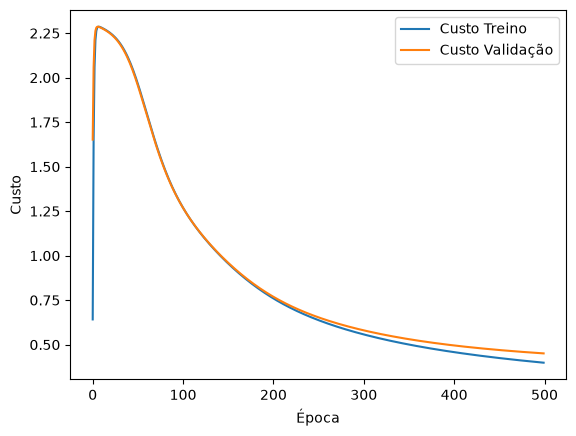

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(logs["epoca"],logs["custo_treino"], label="Custo Treino")
plt.plot(logs["epoca"],logs["custo_validacao"], label="Custo Validação")
plt.xlabel("Época")
plt.ylabel("Custo")
plt.legend()
plt.show()